## Simulator Checks: Recovered Dependence, Lines, and Theta

**- Owner:** Alex

**- Status:** Exploration only. Window 5 is the selection sample from the fit notebook. 2025-26 stays sealed. Do not price from these scores.

**- Last Updated:** 10/5/26

### Purpose

The fit notebook exported a Frank simulator (`artifacts/nba/copula/copula_spec.json`, theta 0.667, tau 0.074). The points backtest in that notebook scored the copula picked on train AIC, which was Student-t, through a quadrature PMF. This notebook scores the exported Frank path.

Four checks, in order:

1. **Recovered dependence.** Draw `U`, invert the minutes sampler, draw `V | U` with `hinv1`, and set points to the NB2 quantile at `V`. Recompute randomized PITs and compare Kendall tau to 0.074, overall and by predicted-minutes tier. Corner lifts at `q = 0.10` and `q = 0.01` are compared across the simulated pairs, the empirical pairs, and the Frank CDF.
2. **Brier and reliability at the lines.** Score `P(over L)` from the conditional NB2 PMF averaged over a minutes grid, against independence and the direct minutes-surprise model. Game-clustered bootstrap intervals. Reliability of `P(over L)` by tier and by line.
3. **Theta sweep.** Frank at theta 0, at the exported 0.667, and at a Frank theta matched to each tier's empirical tau (0.112 at 15-24 minutes versus 0.028 at 31+). If line-level Brier barely moves, more copula work will not change prices.
4. **Market backtest.** Price window 5 points props from `data/backtest/singleBookies.csv` with every setup, including a fully out-of-sample path: count model on windows 1-4, Frank theta from windows 1-4 pairs, and `P(over L)` from Monte Carlo joint draws through the simulator. Log loss against the de-vigged market, a bet rule at `EDGE_THRESHOLD`, ROI by book, and ROI by EV bucket.

### Inputs

The same OOS table, tail sidecars, and pre-holdout gamelogs as the fit notebook. 2025-26 rows are dropped on load. The copula is rebuilt from `copula_spec.json`. Odds: `data/backtest/singleBookies.csv` (2024-25 player props, one snapshot per book), loaded with `models.shared.market.load_single_bookies`.

### Outputs

Tables under `artifacts/nba/copula/simulator_checks/`. Every table carries the seed, the file hashes, the spec status, and which windows entered the parameter.

### Method notes

Minutes and points are discrete enough that a PIT recomputed with an independent atom is not the latent `V`. The wiring check reports three taus: the latent `(U, V)`, the PIT recovered with the atom that inverts the NB2 quantile, and the PIT with a fresh atom. A gap in the first two is a bug in `hinv1` or the quantile inversion. A gap in the third is the integer atom.

The priced PMF averages the conditional NB2 probabilities over a 50-point midpoint grid of `U`. That is the sampling simulator with the Monte Carlo noise removed. A raw tail bin near `p = 0.01` has standard error `sqrt(p(1-p)/N)`, so `10^5` point draws still leave about `±0.0003`, and an empty bin makes the log score infinite. The grid average is the object being scored.

The count model inside the scored PMFs is fit on windows 1-4. The exported theta and the tier taus were fit on windows 1-5, so window 5 is inside those dependence parameters. The market backtest adds a train-only Frank theta so one setup has no window 5 information at all. That is labeled on the tables. It is not a confirmation sample.

Marginal calibration of simulated minutes and points, the PIT of the scored PMF, joint events, cross-player minutes, family swaps, and a multi-seed or multi-window stability check are left for a later notebook.

### 1. Config and Lineage

Hashes are checked against `copula_spec.json`. The OOS table and both tail sidecars have to match that file. The minutes and rate bundles are recorded either way: the spec already says they were saved after the OOS table.


In [1]:
%matplotlib inline

from datetime import datetime, timezone
from hashlib import sha256
import json
from pathlib import Path
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvinecopulib as pv
from IPython.display import Markdown, display
from scipy import stats

def _repo_root() -> Path:
    starts = []
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        starts.append(Path(nb).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pyproject.toml").is_file():
                return candidate
    raise RuntimeError("could not find repo root (pyproject.toml)")

ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.shared.copula import build_pit_pairs, minutes_tier
from models.shared.metrics import (
    PSEUDO_LINE_NAMES,
    binary_brier,
    integer_log_score,
    probability_over,
    pseudo_lines,
    rps,
    seeded_unit_uniform,
    wilson_interval,
)
from models.shared.market import (
    ev_bucket_records,
    load_single_bookies,
    no_vig_over,
    over_given_no_push,
    score_market,
)
from models.shared.minutes_sampler import (
    HOLDOUT_START,
    QUANTILE_LEVELS,
    canonical_id,
    groups_for_frame as minutes_groups,
    load_tail_sidecar as load_minutes_tails,
    ppf as minutes_ppf,
    randomized_pit as minutes_pit,
)
from models.shared.points_given_minutes import (
    conditional_points_pmf,
    copula_corner_lifts,
    corner_lifts,
    count_pit,
    fit_count_model,
    nb_cdf,
)
from models.shared.ppm_sampler import (
    groups_for_frame as rate_groups,
    load_tail_sidecar as load_rate_tails,
    ppf as rate_ppf,
)
from src.features.minutes.rolling import prior_ewm

warnings.filterwarnings("ignore", category=DeprecationWarning, module="pyvinecopulib")

SEED = 42
N_PER_TIER = 50_000
TAIL_QS = (0.10, 0.01)
CORNERS = ("low_u_low_v", "low_u_high_v", "high_u_low_v", "high_u_high_v")
TIERS = ["<15", "15-24", "24-31", "31+"]
PIT_CLIP = 1e-6
V_CLIP = 1e-12
RATE_MEAN_GRID = 200
MINUTES_GRID = 50
KMAX = 90
PMF_BATCH_ROWS = 2_000
SCORE_BOOT_REPS = 1_000
FIXED_LINES = [4.5, 9.5, 14.5, 19.5, 24.5, 29.5]
EWMA_HALFLIFE = 3
TRAIN_WINDOWS = (1, 2, 3, 4)
TEST_WINDOW = 5
TRAIN_LABEL = f"{TRAIN_WINDOWS[0]}-{TRAIN_WINDOWS[-1]}"
ALL_LABEL = f"{TRAIN_WINDOWS[0]}-{TEST_WINDOW}"
HOLDOUT_SEASON = "2025-26"
PREHOLDOUT_SEASONS = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]
STARTER_POSITIONS = ["G", "F", "C"]
INVERSION_ATOL = 1e-5
RELIABILITY_BINS = 10
RELIABILITY_MIN_N = 40
N_SIMS = 4_000
SIM_BATCH_ROWS = 500
SIM_POINTS_CAP = 200

OOS_PATH = ROOT / "data/oos/nba/minutes_rate_oos.parquet"
MINUTES_TAILS_PATH = ROOT / "models/saved_models/min_nba_tails_2026-04-12.joblib"
RATE_TAILS_PATH = ROOT / "models/saved_models/pts_nba_tails_2026-04-12.joblib"
MINUTES_MODEL_PATH = ROOT / "models/saved_models/min_nba_model_2026-04-12.joblib"
PPM_MODEL_PATH = ROOT / "models/saved_models/pts_nba_model_2026-04-12.joblib"
DATA_PATH = ROOT / "data/silver/nba/{season}/regular_season/player_gamelogs.parquet"
SPEC_FILE = ROOT / "artifacts/nba/copula/copula_spec.json"
OUTPUT_PATH = ROOT / "artifacts/nba/copula/simulator_checks"
ODDS_PATH = ROOT / "data/backtest/singleBookies.csv"
ODDS_MIN_BOOKS = 1
ODDS_NAME_ALIASES = {
    "ron holland": "ronald holland",
    "jakob poltl": "jakob poeltl",
    "jamie jaquez": "jaime jaquez",
    "kenyon martin": "kj martin",
    "t vukcevic": "tristan vukcevic",
}
EDGE_THRESHOLD = 0.03
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MINUTES_KNOTS = [f"minutes_q_{level:.2f}" for level in QUANTILE_LEVELS]
RATE_KNOTS = [f"rate_q_{level:.2f}" for level in QUANTILE_LEVELS]
SLICE_ORDER = ["all", *TIERS]
SETUP_ORDER = ["theta_0", "theta_pooled", "theta_tier", "direct"]
SETUP_COLOR = {
    "theta_0": "0.45",
    "theta_pooled": "C0",
    "theta_tier": "C1",
    "direct": "C3",
}
FOCUS_COMPARISONS = (
    ("theta_pooled", "theta_0"),
    ("theta_tier", "theta_0"),
    ("theta_tier", "theta_pooled"),
    ("direct", "theta_0"),
    ("direct", "theta_pooled"),
)

spec = json.loads(SPEC_FILE.read_text())
TARGET_TAU = float(spec["copula"]["tau"])
EXPORTED_THETA = float(spec["copula"]["parameters"][0])


def file_sha256(path: Path) -> str:
    digest = sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1 << 20), b""):
            digest.update(block)
    return digest.hexdigest()


def kendall(a, b) -> float:
    return float(stats.kendalltau(a, b).statistic)


def kendall_se(n: int) -> float:
    """Null standard error of Kendall tau, about 2 / (3 sqrt(n))."""
    return 2.0 / (3.0 * np.sqrt(int(n)))


def frank_copula(theta: float) -> pv.Bicop:
    if abs(theta) < 1e-8:
        return pv.Bicop(family=pv.families.indep)
    return pv.Bicop(
        family=pv.families.frank,
        rotation=0,
        parameters=np.array([[float(theta)]]),
    )


def frank_theta_for_tau(tau: float) -> float:
    """Frank parameter with population Kendall tau equal to `tau`."""
    target = float(tau)
    if abs(target) < 1e-8:
        return 0.0
    lo, hi = (1e-6, 40.0) if target > 0 else (-40.0, -1e-6)
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        value = float(frank_copula(mid).tau)
        if value < target:
            lo = mid
        else:
            hi = mid
    theta = 0.5 * (lo + hi)
    if abs(float(frank_copula(theta).tau) - target) > 1e-5:
        raise RuntimeError(f"Frank inversion failed for tau {target}")
    return float(theta)


def nb_ppf(v, mu, alpha) -> np.ndarray:
    size = 1.0 / np.asarray(alpha, dtype=float)
    prob = size / (size + np.asarray(mu, dtype=float))
    q = np.clip(np.asarray(v, dtype=float), V_CLIP, 1.0 - V_CLIP)
    return stats.nbinom.ppf(q, size, prob)


def inversion_atom(points, mu, alpha, v) -> tuple[np.ndarray, np.ndarray]:
    """Atom `w` such that the randomized PIT of `points` returns `v`."""
    left = nb_cdf(np.asarray(points, dtype=float) - 1, mu, alpha)
    right = nb_cdf(points, mu, alpha)
    width = right - left
    atom = np.zeros(np.shape(width), dtype=float)
    positive = width > 1e-15
    atom[positive] = (np.asarray(v, dtype=float)[positive] - left[positive]) / width[positive]
    return np.clip(atom, 0.0, 1.0), width


def game_bootstrap(diff, games, n_boot: int, seed: int) -> tuple[float, float, float, int]:
    finite = np.isfinite(diff)
    codes, _ = pd.factorize(np.asarray(games)[finite])
    sums = np.bincount(codes, weights=np.asarray(diff, dtype=float)[finite])
    counts = np.bincount(codes).astype(float)
    draws = np.random.default_rng(seed).integers(0, len(sums), size=(n_boot, len(sums)))
    boot = sums[draws].sum(axis=1) / counts[draws].sum(axis=1)
    low, high = np.quantile(boot, [0.025, 0.975])
    return float(np.mean(diff[finite])), float(low), float(high), int(len(sums))


def slice_masks(labels) -> list[tuple[str, np.ndarray]]:
    labels = np.asarray(labels)
    masks = [("all", np.ones(labels.shape[0], dtype=bool))]
    for name in TIERS:
        masks.append((name, labels == name))
    return masks

In [2]:
lineage_rows = []
for name, meta in spec["lineage"]["files"].items():
    path = ROOT / meta["path"]
    digest = file_sha256(path) if path.is_file() else ""
    lineage_rows.append({
        "name": name,
        "path": meta["path"],
        "sha256": digest[:12],
        "spec_sha256": meta["sha256"][:12],
        "match": digest == meta["sha256"],
        "modified": datetime.fromtimestamp(path.stat().st_mtime, timezone.utc).isoformat() if path.is_file() else "",
    })
lineage = pd.DataFrame(lineage_rows).set_index("name")
display(lineage)
required = ["oos_table", "minutes_tails", "rate_tails"]
missing = [name for name in required if not bool(lineage.loc[name, "match"])]
if missing:
    raise RuntimeError(f"lineage mismatch on {missing}; this is not the exported fold")

LINEAGE_STAMP = {
    "seed": SEED,
    "spec_status": spec["status"],
    f"window_{TEST_WINDOW}_role": "selection_sample",
    "holdout_2025_26": "sealed",
    "oos_sha256": lineage.loc["oos_table", "sha256"],
    "minutes_tails_sha256": lineage.loc["minutes_tails", "sha256"],
    "rate_tails_sha256": lineage.loc["rate_tails", "sha256"],
    "minutes_bundle_sha256": lineage.loc["minutes_bundle", "sha256"],
    "ppm_bundle_sha256": lineage.loc["ppm_bundle", "sha256"],
    "family": spec["copula"]["family"],
    "exported_theta": EXPORTED_THETA,
    "exported_tau": TARGET_TAU,
}
print(f"Spec status: {spec['status']}")
print(f"Exported {spec['copula']['family']} theta {EXPORTED_THETA:.6f}, tau {TARGET_TAU:.6f}, seed {SEED}")
for warning in spec["lineage"]["warnings"]:
    print(f"Spec warning: {warning}")


def with_stamp(frame: pd.DataFrame, **extra) -> pd.DataFrame:
    out = frame.copy()
    for key, value in {**LINEAGE_STAMP, **extra}.items():
        out[key] = value
    return out

,path,sha256,spec_sha256,match,modified
name,,,,,
oos_table,data/oos/nba/minutes_rate_oos.parquet,56382e99b513,56382e99b513,True,2026-09-27T05:33:08.644500+00:00
minutes_tails,models/saved_models/min_nba_tails_2026-04-12.j...,3800ce3c70ce,3800ce3c70ce,True,2026-09-26T19:07:52.770574+00:00
rate_tails,models/saved_models/pts_nba_tails_2026-04-12.j...,b6db7d2dd664,b6db7d2dd664,True,2026-09-27T06:06:51.278083+00:00
minutes_bundle,models/saved_models/min_nba_model_2026-04-12.j...,629e860eca26,629e860eca26,True,2026-10-04T02:13:24.560984+00:00
ppm_bundle,models/saved_models/pts_nba_model_2026-04-12.j...,dc51c2ca84dd,dc51c2ca84dd,True,2026-10-04T16:37:04.813181+00:00
gamelogs_2019-20,data/silver/nba/2019-20/regular_season/player_...,1e69babd527c,1e69babd527c,True,2026-09-13T04:15:34.206270+00:00
gamelogs_2020-21,data/silver/nba/2020-21/regular_season/player_...,53a0f424d474,53a0f424d474,True,2026-09-13T04:02:04.379038+00:00
gamelogs_2021-22,data/silver/nba/2021-22/regular_season/player_...,7af48f3ce7c7,7af48f3ce7c7,True,2026-09-11T02:08:51.973792+00:00
gamelogs_2022-23,data/silver/nba/2022-23/regular_season/player_...,34448e7b8742,34448e7b8742,True,2026-09-11T02:29:31.377609+00:00


Spec status: exploratory_oos
Exported frank theta 0.667364, tau 0.073824, seed 42
Spec warning: minutes_bundle was saved after the OOS table, so the pairs describe the earlier fold models.
Spec warning: ppm_bundle was saved after the OOS table, so the pairs describe the earlier fold models.


### 2. Pairs and the Exported Simulator

`u_minutes` is the randomized PIT of realized minutes. `u_points` is the randomized PIT of realized points under the NB2 count model with actual minutes as exposure. Both use the same seeds as the fit notebook. The count model is refit here and every coefficient is checked against `copula_spec.json`.

The scored PMFs later use a second count-model fit, on windows 1-4 only, plus a direct model that adds `Phi^{-1}(u_minutes)` to the log mean. Window 5 does not enter those two fits.

In [3]:
t0 = time.perf_counter()
oos_all = pd.read_parquet(OOS_PATH)
n_holdout_dropped = int(oos_all["is_holdout"].astype(bool).sum())
rows = oos_all.loc[~oos_all["is_holdout"].astype(bool)].reset_index(drop=True)
del oos_all
rows["game_date"] = pd.to_datetime(rows["game_date"])
assert int(len(rows)) == int(spec["pairs"]["n_pairs"])
assert rows["window_id"].gt(0).all()
assert rows["game_date"].max() < pd.Timestamp(HOLDOUT_START)
assert str(rows["game_date"].min().date()) == spec["pairs"]["date_range"][0]
assert str(rows["game_date"].max().date()) == spec["pairs"]["date_range"][1]

panel = pd.concat(
    [
        pd.read_parquet(
            str(DATA_PATH).format(season=season),
            columns=["season_year", "game_id", "player_id", "game_date", "pts", "minutes",
                     "start_position", "player_team_spread"],
        )
        for season in PREHOLDOUT_SEASONS
    ],
    ignore_index=True,
)
panel = panel.loc[panel["minutes"].astype(float) > 0].copy()
panel["pts"] = panel["pts"].astype(float)
panel["game_date"] = pd.to_datetime(panel["game_date"])
panel = panel.sort_values(["game_date", "game_id", "player_id"], kind="mergesort").reset_index(drop=True)
panel["starting"] = panel["start_position"].astype("string").str.strip().isin(STARTER_POSITIONS).astype(int)
panel["pts_ewm"] = prior_ewm(panel, "pts", ["player_id"], halflife=EWMA_HALFLIFE)
for frame in (panel, rows):
    frame["game_key"] = frame["game_id"].map(canonical_id)
    frame["player_key"] = frame["player_id"].map(canonical_id)

rows = rows.merge(
    panel[["game_key", "player_key", "season_year", "starting", "player_team_spread", "pts_ewm"]],
    on=["game_key", "player_key"],
    how="left",
    validate="one_to_one",
)
assert rows["starting"].notna().all(), "OOS rows without a gamelog match"
rows["starting"] = rows["starting"].astype(int)
rows["tier"] = minutes_tier(rows["minutes_q_0.50"])

minutes_tables = load_minutes_tails(MINUTES_TAILS_PATH)
rate_tables = load_rate_tails(RATE_TAILS_PATH)
pairs = build_pit_pairs(rows, minutes_tables=minutes_tables, rate_tables=rate_tables, seed=SEED)
assert len(pairs) == len(rows)
rows["u_minutes"] = pairs["u_m"].to_numpy()
del pairs


def rate_moments(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    grid_u = (np.arange(RATE_MEAN_GRID) + 0.5) / RATE_MEAN_GRID
    lower, upper = rate_groups(frame["starting"], rate_tables)
    draws = rate_ppf(
        np.tile(grid_u, (len(frame), 1)),
        frame[RATE_KNOTS].to_numpy(dtype=float),
        lower,
        upper,
        rate_tables,
    )
    mean = draws.mean(axis=1)
    return mean, draws.std(axis=1) / np.maximum(mean, 1e-9)


rows["rate_hat"], rows["rate_cv"] = rate_moments(rows)
rows["points_atom"] = seeded_unit_uniform(rows["player_id"], rows["game_id"], seed=SEED, label="pit_points")
count_all = fit_count_model(rows["minutes"], rows["pts"], rows["rate_hat"], rate_cv=rows["rate_cv"])
for name in ("log_kappa", "beta", "log_alpha", "beta2", "alpha_minutes", "alpha_cv", "gamma"):
    got = float(getattr(count_all, name))
    stored = float(spec["count_model"][name])
    if abs(got - stored) > 1e-4:
        raise RuntimeError(f"count model {name}: refit {got} vs spec {stored}")
rows["u_points"] = count_pit(
    rows["pts"],
    count_all.mean(rows["minutes"], rows["rate_hat"]),
    count_all.alpha(rows["minutes"], rows["rate_cv"]),
    rows["points_atom"],
)
uv = np.column_stack([
    np.clip(rows["u_minutes"].to_numpy(dtype=float), PIT_CLIP, 1 - PIT_CLIP),
    np.clip(rows["u_points"].to_numpy(dtype=float), PIT_CLIP, 1 - PIT_CLIP),
])
exported = pv.Bicop.from_json(spec["copula"]["pyvinecopulib_json"])
rebuilt_ll = float(exported.loglik(uv))
if abs(rebuilt_ll - float(spec["copula"]["loglik"])) > 1e-2:
    raise RuntimeError(f"rebuilt loglik {rebuilt_ll} vs spec {spec['copula']['loglik']}")
if abs(float(exported.tau) - TARGET_TAU) > 1e-12:
    raise RuntimeError("exported tau")

train = rows.loc[rows["window_id"].isin(TRAIN_WINDOWS)].reset_index(drop=True)
test = rows.loc[rows["window_id"].eq(TEST_WINDOW)].reset_index(drop=True)
assert train["game_date"].max() < test["game_date"].min()
count_tr = fit_count_model(train["minutes"], train["pts"], train["rate_hat"], rate_cv=train["rate_cv"])
surprise_tr = stats.norm.ppf(np.clip(train["u_minutes"], PIT_CLIP, 1 - PIT_CLIP))
direct_tr = fit_count_model(
    train["minutes"], train["pts"], train["rate_hat"], rate_cv=train["rate_cv"], surprise=surprise_tr,
)
print(f"Holdout rows dropped on load : {n_holdout_dropped:,}")
print(f"Pre-holdout rows             : {len(rows):,}  ({time.perf_counter() - t0:.0f}s)")
print(f"Windows {TRAIN_WINDOWS}: {len(train):,}   window {TEST_WINDOW} (selection sample): {len(test):,}")
print(f"Rebuilt Frank loglik {rebuilt_ll:,.2f} matches the spec.")
display(pd.DataFrame({
    f"count model, windows {ALL_LABEL}": count_all.to_dict(),
    f"count model, windows {TRAIN_LABEL}": count_tr.to_dict(),
    f"direct model, windows {TRAIN_LABEL}": direct_tr.to_dict(),
}).round(4))

Holdout rows dropped on load : 26,648
Pre-holdout rows             : 60,443  (50s)
Windows (1, 2, 3): 45,002   window 4 (selection sample): 15,441
Rebuilt Frank loglik 379.03 matches the spec.


,"count model, windows 1-4","count model, windows 1-3","direct model, windows 1-3"
log_kappa,-0.2461,-0.2757,0.0371
beta,1.0785,1.0860,0.9896
log_alpha,-1.4567,-1.4734,-1.5554
beta2,-0.0022,0.0005,-0.0442
alpha_minutes,-1.1443,-1.1545,-1.1936
alpha_cv,0.8374,0.8355,0.7467
gamma,0.0000,0.0000,0.0614
minutes_center,24.0000,24.0000,24.0000


### 3. Recovered Tau and Corner Lifts

Each draw picks a pre-holdout row inside one predicted-minutes tier, then follows the exported simulator: `U` through the minutes quantile function, `V | U` through Frank `hinv1`, points at the NB2 quantile of `V` given those minutes and that row's rate moments. The count model here is the windows 1-5 fit, which is the exported one.

Fifty thousand draws per tier. The null standard error of Kendall tau at that size is about 0.003, so a wiring error of 0.01 is visible. Theoretical lifts come from the Frank CDF and do not depend on the tier, because the exported copula is pooled.

In [4]:
probe = np.random.default_rng(SEED + 7).random((2_000, 2))
probe_v = np.asarray(exported.hinv1(probe), dtype=float)
probe_back = np.asarray(exported.hfunc1(np.column_stack([probe[:, 0], probe_v])), dtype=float)
if np.max(np.abs(probe_back - probe[:, 1])) > 1e-8:
    raise RuntimeError("hinv1 is not the inverse of hfunc1")

row_rng = np.random.default_rng(SEED + 1)
sim_rng = np.random.default_rng(SEED + 2)
chunks = []
diag_rows = []
for tier in TIERS:
    started = time.perf_counter()
    pool = np.flatnonzero(rows["tier"].to_numpy() == tier)
    chosen = row_rng.choice(pool, size=N_PER_TIER, replace=True)
    sample = rows.iloc[chosen]
    grids = sample[MINUTES_KNOTS].to_numpy(dtype=float)
    lower, upper = minutes_groups(sample["starting"], minutes_tables)
    u = sim_rng.random(N_PER_TIER)
    w = sim_rng.random(N_PER_TIER)
    v = np.clip(np.asarray(exported.hinv1(np.column_stack([u, w])), dtype=float), V_CLIP, 1.0 - V_CLIP)
    minutes_sim = minutes_ppf(u.reshape(-1, 1), grids, lower, upper, minutes_tables)[:, 0]
    mu = count_all.mean(minutes_sim, sample["rate_hat"].to_numpy(dtype=float))
    alpha = count_all.alpha(minutes_sim, sample["rate_cv"].to_numpy(dtype=float))
    points = nb_ppf(v, mu, alpha)
    if np.max(np.abs(points - np.rint(points))) > 1e-6:
        raise RuntimeError("NB2 quantile did not land on an integer")
    inv_atom, atom_width = inversion_atom(points, mu, alpha, v)
    u_points_inv = count_pit(points, mu, alpha, inv_atom)
    inv_error = np.abs(u_points_inv - v)
    if float(np.max(inv_error)) > INVERSION_ATOL:
        raise RuntimeError(f"{tier} NB2 inversion error {np.max(inv_error)}")
    u_minutes_rt = minutes_pit(minutes_sim, sim_rng.random(N_PER_TIER), grids, lower, upper, minutes_tables)
    u_points_rt = count_pit(points, mu, alpha, sim_rng.random(N_PER_TIER))
    minute_error = np.abs(u_minutes_rt - u)
    chunks.append(pd.DataFrame({
        "tier": tier,
        "u": u,
        "v": v,
        "u_minutes_rt": u_minutes_rt,
        "u_points_inv": u_points_inv,
        "u_points_rt": u_points_rt,
    }))
    diag_rows.append({
        "tier": tier,
        "n": N_PER_TIER,
        "max_points_inversion_error": float(np.max(inv_error)),
        "mean_points_atom_width": float(np.mean(atom_width)),
        "mean_minutes_pit_error": float(np.mean(minute_error)),
        "max_minutes_pit_error": float(np.max(minute_error)),
    })
    print(f"{tier}: {N_PER_TIER:,} draws in {time.perf_counter() - started:.1f}s, "
          f"mean points atom width {np.mean(atom_width):.4f}")

sim = pd.concat(chunks, ignore_index=True)
roundtrip_diag = pd.DataFrame(diag_rows)
display(roundtrip_diag.round(6))
print("Points inversion error is the gap between V and the PIT recovered with the inverting atom. "
      "Minutes PIT error is |randomized PIT of Q(U) - U|.")


<15: 50,000 draws in 15.2s, mean points atom width 0.2438
15-24: 50,000 draws in 15.3s, mean points atom width 0.0905
24-31: 50,000 draws in 14.6s, mean points atom width 0.0624
31+: 50,000 draws in 14.3s, mean points atom width 0.0452


,tier,n,max_points_inversion_error,mean_points_atom_width,mean_minutes_pit_error,max_minutes_pit_error
0,<15,50000,0.0,0.243817,0.000009,0.165044
1,15-24,50000,0.0,0.090512,0.000000,0.000013
2,24-31,50000,0.0,0.062402,0.000000,0.000013
3,31+,50000,0.0,0.045245,0.000000,0.000000


Points inversion error is the gap between V and the PIT recovered with the inverting atom. Minutes PIT error is |randomized PIT of Q(U) - U|.


,slice,n_sim,n_empirical,target_tau,empirical_tau,latent_tau,inversion_tau,roundtrip_tau,latent_minus_target,roundtrip_minus_latent,null_se,mean_points_atom_width
0,all,200000,60443,0.0738,0.0741,0.0744,0.0744,0.0698,0.0006,-0.0046,0.0015,0.1105
1,<15,50000,15081,0.0738,0.0838,0.0775,0.0775,0.0616,0.0037,-0.0158,0.0030,0.2438
2,15-24,50000,14977,0.0738,0.1117,0.0732,0.0732,0.0717,-0.0007,-0.0015,0.0030,0.0905
3,24-31,50000,14457,0.0738,0.0787,0.0725,0.0725,0.0715,-0.0013,-0.0011,0.0030,0.0624
4,31+,50000,15928,0.0738,0.0275,0.0744,0.0744,0.0743,0.0006,-0.0001,0.0030,0.0452


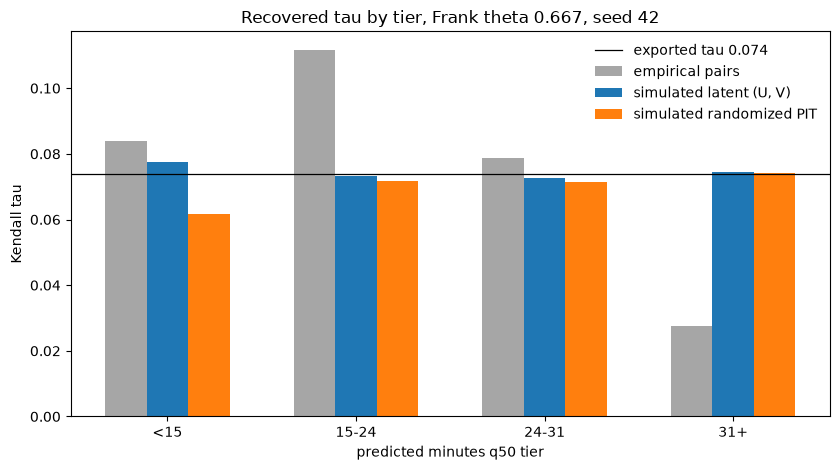

In [5]:
tau_rows = []
for slice_name, mask in slice_masks(sim["tier"].to_numpy()):
    if slice_name == "all":
        empirical_mask = np.ones(len(rows), dtype=bool)
    else:
        empirical_mask = rows["tier"].to_numpy() == slice_name
    n_sim = int(mask.sum())
    latent = kendall(sim.loc[mask, "u"], sim.loc[mask, "v"])
    inversion = kendall(sim.loc[mask, "u"], sim.loc[mask, "u_points_inv"])
    roundtrip = kendall(sim.loc[mask, "u_minutes_rt"], sim.loc[mask, "u_points_rt"])
    empirical = kendall(rows.loc[empirical_mask, "u_minutes"], rows.loc[empirical_mask, "u_points"])
    tau_rows.append({
        "slice": slice_name,
        "n_sim": n_sim,
        "n_empirical": int(empirical_mask.sum()),
        "target_tau": TARGET_TAU,
        "empirical_tau": empirical,
        "latent_tau": latent,
        "inversion_tau": inversion,
        "roundtrip_tau": roundtrip,
        "latent_minus_target": latent - TARGET_TAU,
        "roundtrip_minus_latent": roundtrip - latent,
        "null_se": kendall_se(n_sim),
        "mean_points_atom_width": float(roundtrip_diag.loc[roundtrip_diag["tier"].eq(slice_name), "mean_points_atom_width"].iloc[0])
        if slice_name != "all" else float(np.average(
            roundtrip_diag["mean_points_atom_width"], weights=roundtrip_diag["n"]
        )),
    })
tau_table = pd.DataFrame(tau_rows)
tau_table["slice"] = pd.Categorical(tau_table["slice"], SLICE_ORDER, ordered=True)
tau_table = tau_table.sort_values("slice").reset_index(drop=True)
display(tau_table.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(TIERS))
width = 0.22
view = tau_table.set_index("slice").loc[TIERS]
ax.bar(x - width, view["empirical_tau"], width, label="empirical pairs", color="0.65")
ax.bar(x, view["latent_tau"], width, label="simulated latent (U, V)", color="C0")
ax.bar(x + width, view["roundtrip_tau"], width, label="simulated randomized PIT", color="C1")
ax.axhline(TARGET_TAU, color="black", lw=0.9, label=f"exported tau {TARGET_TAU:.3f}")
ax.set_xticks(x)
ax.set_xticklabels(TIERS)
ax.set_ylabel("Kendall tau")
ax.set_xlabel("predicted minutes q50 tier")
ax.set_title(f"Recovered tau by tier, Frank theta {EXPORTED_THETA:.3f}, seed {SEED}")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


,slice,q,corner,empirical_count,empirical,latent,latent_count,roundtrip,roundtrip_count,theoretical
0,all,0.01,low_u_low_v,7,1.158,1.400,28,1.200,24,1.361
1,all,0.01,low_u_high_v,5,0.827,0.950,19,1.050,21,0.708
2,all,0.01,high_u_low_v,7,1.158,0.850,17,0.850,17,0.708
3,all,0.01,high_u_high_v,15,2.482,1.450,29,1.500,30,1.361
4,<15,0.01,low_u_low_v,2,1.326,1.000,5,0.600,3,1.361
5,<15,0.01,low_u_high_v,2,1.326,0.800,4,1.400,7,0.708
6,<15,0.01,high_u_low_v,2,1.326,0.800,4,1.200,6,0.708
7,<15,0.01,high_u_high_v,5,3.315,1.400,7,1.400,7,1.361
8,15-24,0.01,low_u_low_v,2,1.335,2.000,10,1.800,9,1.361
9,15-24,0.01,low_u_high_v,1,0.668,1.800,9,1.800,9,0.708


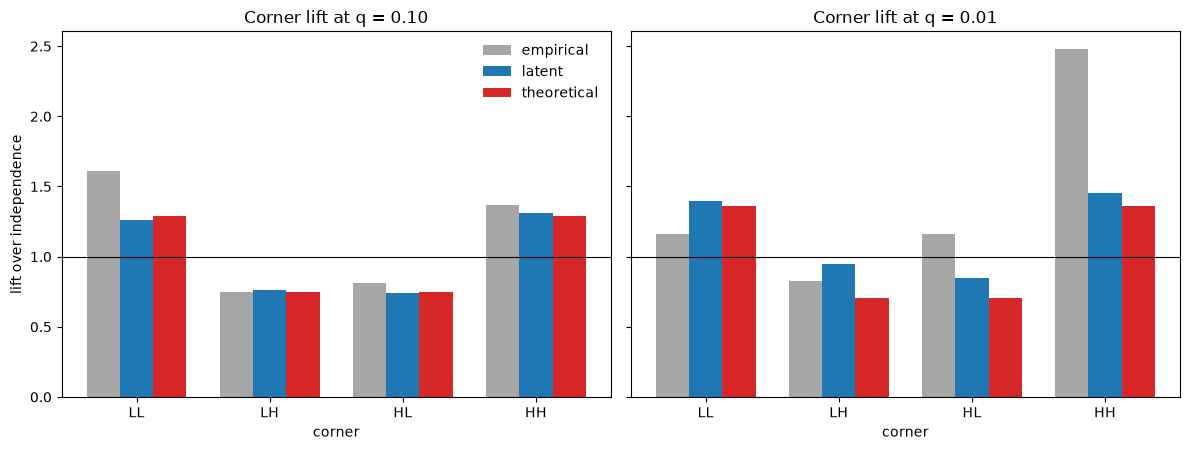

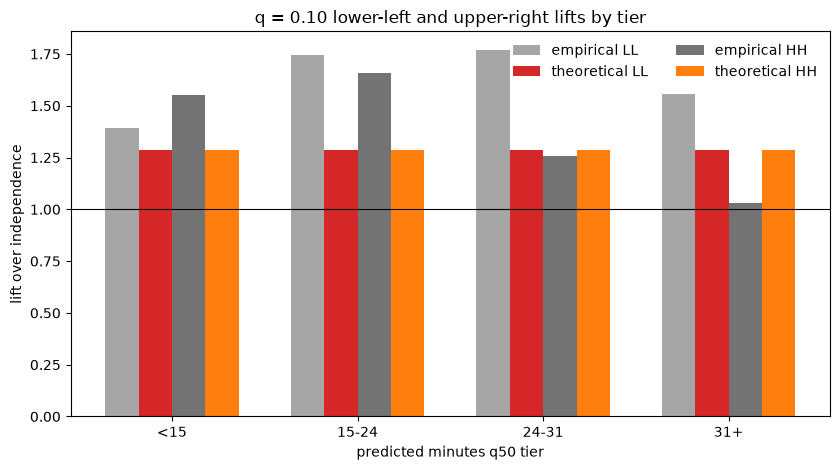

In [6]:
def _corner_frame(u, v, labels, source: str) -> pd.DataFrame:
    records = []
    for slice_name, mask in slice_masks(labels):
        for row in corner_lifts(np.asarray(u)[mask], np.asarray(v)[mask], TAIL_QS):
            row["slice"] = slice_name
            row["source"] = source
            records.append(row)
    return pd.DataFrame(records)


empirical_corners = _corner_frame(rows["u_minutes"], rows["u_points"], rows["tier"], "empirical")
latent_corners = _corner_frame(sim["u"], sim["v"], sim["tier"], "latent")
roundtrip_corners = _corner_frame(sim["u_minutes_rt"], sim["u_points_rt"], sim["tier"], "roundtrip")
theoretical = pd.DataFrame(copula_corner_lifts(exported, TAIL_QS))
theoretical["source"] = "theoretical"
theoretical["slice"] = "all"
theoretical_rows = []
for slice_name in SLICE_ORDER:
    part = theoretical.drop(columns="slice").copy()
    part["slice"] = slice_name
    theoretical_rows.append(part)
theoretical = pd.concat(theoretical_rows, ignore_index=True)

pieces = {
    "empirical": empirical_corners,
    "latent": latent_corners,
    "roundtrip": roundtrip_corners,
    "theoretical": theoretical,
}
corner_wide = pieces["empirical"][["slice", "q", "corner", "count", "lift"]].rename(
    columns={"count": "empirical_count", "lift": "empirical"}
)
for source, frame in pieces.items():
    if source == "empirical":
        continue
    keep = frame[["slice", "q", "corner", "lift"]].rename(columns={"lift": source})
    if "count" in frame.columns and source != "theoretical":
        keep[f"{source}_count"] = frame["count"].to_numpy()
    corner_wide = corner_wide.merge(keep, on=["slice", "q", "corner"], how="left")
corner_wide["slice"] = pd.Categorical(corner_wide["slice"], SLICE_ORDER, ordered=True)
corner_wide["corner"] = pd.Categorical(corner_wide["corner"], CORNERS, ordered=True)
corner_wide = corner_wide.sort_values(["q", "slice", "corner"]).reset_index(drop=True)
display(corner_wide.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
sources = ("empirical", "latent", "theoretical")
colors = ("0.65", "C0", "C3")
for ax, q in zip(axes, TAIL_QS):
    part = corner_wide.loc[(corner_wide["slice"] == "all") & np.isclose(corner_wide["q"], q)]
    part = part.set_index("corner").loc[list(CORNERS)]
    x = np.arange(len(CORNERS))
    width = 0.25
    for offset, source, color in zip((-width, 0.0, width), sources, colors):
        ax.bar(x + offset, part[source], width, label=source, color=color)
    ax.axhline(1.0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(["LL", "LH", "HL", "HH"])
    ax.set_title(f"Corner lift at q = {q:.2f}")
    ax.set_xlabel("corner")
axes[0].set_ylabel("lift over independence")
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
q10 = corner_wide.loc[np.isclose(corner_wide["q"], 0.10)]
x = np.arange(len(TIERS))
width = 0.18
series = (
    ("empirical", "low_u_low_v", "empirical LL", "0.65"),
    ("theoretical", "low_u_low_v", "theoretical LL", "C3"),
    ("empirical", "high_u_high_v", "empirical HH", "0.45"),
    ("theoretical", "high_u_high_v", "theoretical HH", "C1"),
)
for index, (source, corner, label, color) in enumerate(series):
    heights = [
        float(q10.loc[(q10["slice"] == tier) & (q10["corner"] == corner), source].iloc[0])
        for tier in TIERS
    ]
    ax.bar(x + (index - 1.5) * width, heights, width, label=label, color=color)
ax.axhline(1.0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TIERS)
ax.set_ylabel("lift over independence")
ax.set_xlabel("predicted minutes q50 tier")
ax.set_title("q = 0.10 lower-left and upper-right lifts by tier")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


### 4. Brier and Reliability at the Lines

The four scored distributions are the theta sweep. Independence is theta 0. `theta_pooled` is the exported Frank parameter. `theta_tier` is a Frank copula in each predicted-minutes tier, with theta chosen so the population tau matches that tier's Kendall tau on all pre-holdout pairs. `direct` refits the count model on windows 1-4 with the minutes surprise in the log mean and uses no copula.

`P(over L)` is read from the quadrature PMF. Lines are the half-point pseudo-lines around `floor(EWMA halflife 3) + 0.5`, and the fixed half-point lines from 4.5 to 29.5. Lower Brier is better. Intervals are a 95% bootstrap over games. Window 5 is the selection sample, and the tier taus and the pooled theta were estimated on windows 1-5.

In [7]:
tier_rows = []
for tier in TIERS:
    mask = rows["tier"].to_numpy() == tier
    train_mask = train["tier"].to_numpy() == tier
    tau_all = kendall(rows.loc[mask, "u_minutes"], rows.loc[mask, "u_points"])
    tau_train = kendall(train.loc[train_mask, "u_minutes"], train.loc[train_mask, "u_points"])
    theta = frank_theta_for_tau(tau_all)
    tier_rows.append({
        "tier": tier,
        "n_all_windows": int(mask.sum()),
        "tau_all_windows": tau_all,
        "tau_train_windows": tau_train,
        "frank_theta": theta,
        "frank_tau_check": float(frank_copula(theta).tau),
        "theta_source": f"windows_{ALL_LABEL}_empirical_tau",
    })
tier_thetas = pd.DataFrame(tier_rows)
display(tier_thetas.round(4))
tier_copulas = {row.tier: frank_copula(row.frank_theta) for row in tier_thetas.itertuples()}
pooled_copula = frank_copula(EXPORTED_THETA)

u_grid = (np.arange(MINUTES_GRID) + 0.5) / MINUTES_GRID
lower, upper = minutes_groups(test["starting"], minutes_tables)
minutes_at_u = minutes_ppf(
    np.tile(u_grid, (len(test), 1)),
    test[MINUTES_KNOTS].to_numpy(dtype=float),
    lower,
    upper,
    minutes_tables,
)
rate_hat_te = test["rate_hat"].to_numpy(dtype=float)
rate_cv_te = test["rate_cv"].to_numpy(dtype=float)


def points_pmf(model, bicops, use_surprise: bool = False) -> np.ndarray:
    out = np.zeros((len(test), KMAX + 1))
    tiers = test["tier"].to_numpy()
    for tier in TIERS:
        index = np.flatnonzero(tiers == tier)
        bicop = bicops[tier] if isinstance(bicops, dict) else bicops
        for start in range(0, len(index), PMF_BATCH_ROWS):
            block = index[start:start + PMF_BATCH_ROWS]
            out[block] = conditional_points_pmf(
                minutes_at_u[block],
                u_grid,
                rate_hat_te[block],
                model,
                kmax=KMAX,
                rate_cv=rate_cv_te[block],
                bicop=bicop,
                use_surprise=use_surprise,
            )
    if not np.allclose(out.sum(axis=1), 1.0):
        raise RuntimeError("PMF rows do not sum to 1")
    return out


pmf_specs = {
    "theta_0": dict(model=count_tr, bicops=None, use_surprise=False),
    "theta_pooled": dict(model=count_tr, bicops=pooled_copula, use_surprise=False),
    "theta_tier": dict(model=count_tr, bicops=tier_copulas, use_surprise=False),
    "direct": dict(model=direct_tr, bicops=None, use_surprise=True),
}
pmfs = {}
for name, kwargs in pmf_specs.items():
    started = time.perf_counter()
    pmfs[name] = points_pmf(**kwargs)
    print(f"{name}: {len(test):,} PMFs in {time.perf_counter() - started:.1f}s")

,tier,n_windows_1_4,tau_windows_1_4,tau_windows_1_3,frank_theta,frank_tau_check,theta_source
0,<15,15081,0.0838,0.0832,0.7588,0.0838,windows_1_4_empirical_tau
1,15-24,14977,0.1117,0.1076,1.0159,0.1117,windows_1_4_empirical_tau
2,24-31,14457,0.0787,0.0846,0.7120,0.0787,windows_1_4_empirical_tau
3,31+,15928,0.0275,0.0260,0.2479,0.0275,windows_1_4_empirical_tau


theta_0: 15,441 PMFs in 17.1s
theta_pooled: 15,441 PMFs in 22.2s
theta_tier: 15,441 PMFs in 22.2s
direct: 15,441 PMFs in 17.1s


In [8]:
y_te = test["pts"].to_numpy(dtype=float)
games_te = test["game_key"].to_numpy()
tiers_te = test["tier"].to_numpy()
lines_pseudo = pseudo_lines(test["pts_ewm"].to_numpy(dtype=float))
line_sets = {name: lines_pseudo[:, i] for i, name in enumerate(PSEUDO_LINE_NAMES)}
line_sets.update({f"fixed {line:g}": np.full(len(test), line) for line in FIXED_LINES})
LINE_ORDER = list(line_sets)


def row_brier(pmf, lines) -> np.ndarray:
    valid = np.isfinite(lines)
    out = np.full(len(lines), np.nan)
    if np.any(valid):
        probability = probability_over(pmf[valid], lines[valid])
        out[valid] = binary_brier(probability, y_te[valid] > lines[valid])
    return out


row_metrics = {}
for name, pmf in pmfs.items():
    metrics = {
        "log_score": integer_log_score(pmf, y_te),
        "rps": rps(pmf, y_te),
    }
    for line_name, lines in line_sets.items():
        metrics[f"brier {line_name}"] = row_brier(pmf, lines)
    row_metrics[name] = metrics

level_rows = []
for setup in SETUP_ORDER:
    for slice_name, mask in slice_masks(tiers_te):
        record = {
            "setup": setup,
            "slice": slice_name,
            "n": int(mask.sum()),
            "log_score": float(np.mean(row_metrics[setup]["log_score"][mask])),
            "rps": float(np.mean(row_metrics[setup]["rps"][mask])),
        }
        for line_name in LINE_ORDER:
            values = row_metrics[setup][f"brier {line_name}"][mask]
            record[f"brier {line_name}"] = float(np.nanmean(values))
            record[f"n {line_name}"] = int(np.isfinite(values).sum())
        level_rows.append(record)
levels = pd.DataFrame(level_rows)
levels["setup"] = pd.Categorical(levels["setup"], SETUP_ORDER, ordered=True)
levels["slice"] = pd.Categorical(levels["slice"], SLICE_ORDER, ordered=True)
levels = levels.sort_values(["slice", "setup"]).reset_index(drop=True)

BETTER_IF = {"log_score": "positive", "rps": "negative"}
for line_name in LINE_ORDER:
    BETTER_IF[f"brier {line_name}"] = "negative"

diff_rows = []
for right, left in FOCUS_COMPARISONS:
    for slice_name, mask in slice_masks(tiers_te):
        metrics = ["log_score", "rps", "brier L0"]
        if slice_name == "all":
            metrics = ["log_score", "rps", *[f"brier {name}" for name in LINE_ORDER]]
        for metric in metrics:
            diff = row_metrics[right][metric][mask] - row_metrics[left][metric][mask]
            mean, low, high, n_games = game_bootstrap(diff, games_te[mask], SCORE_BOOT_REPS, SEED)
            diff_rows.append({
                "comparison": f"{right} - {left}",
                "right": right,
                "left": left,
                "metric": metric,
                "slice": slice_name,
                "better_if": BETTER_IF[metric],
                "mean_diff": mean,
                "ci_low": low,
                "ci_high": high,
                "n_games": n_games,
                "significant": bool(low > 0 or high < 0),
            })
diffs = pd.DataFrame(diff_rows)

print(f"Window {TEST_WINDOW} selection sample. Log score: higher is better. RPS and Brier: lower is better.")
show_cols = ["setup", "slice", "n", "log_score", "rps", "brier L0", "brier fixed 9.5", "brier fixed 19.5", "brier fixed 29.5"]
display(levels.loc[:, show_cols].round(5))
focus = diffs.loc[diffs["metric"].isin(["log_score", "rps", "brier L0"])]
display(focus.round(5))

Window 4 selection sample. Log score: higher is better. RPS and Brier: lower is better.


,setup,slice,n,log_score,rps,brier L0,brier fixed 9.5,brier fixed 19.5,brier fixed 29.5
0,theta_0,all,15441,-2.94792,3.08822,0.23576,0.14811,0.08153,0.02826
1,theta_pooled,all,15441,-2.94203,3.08452,0.23534,0.14775,0.08150,0.02828
2,theta_tier,all,15441,-2.94150,3.08375,0.23526,0.14772,0.08150,0.02827
3,direct,all,15441,-2.94443,3.08380,0.23503,0.14751,0.08178,0.02832
4,theta_0,<15,4040,-2.28526,1.99062,0.23481,0.08136,0.00730,0.00074
5,theta_pooled,<15,4040,-2.27787,1.98465,0.23394,0.08097,0.00728,0.00074
6,theta_tier,<15,4040,-2.27720,1.98410,0.23384,0.08093,0.00728,0.00074
7,direct,<15,4040,-2.27918,1.97789,0.23280,0.08076,0.00728,0.00074
8,theta_0,15-24,3770,-2.94370,2.87477,0.23447,0.19695,0.02861,0.00133
9,theta_pooled,15-24,3770,-2.93571,2.86935,0.23388,0.19629,0.02865,0.00133


,comparison,right,left,metric,slice,better_if,mean_diff,ci_low,ci_high,n_games,significant
0,theta_pooled - theta_0,theta_pooled,theta_0,log_score,all,positive,0.00589,0.00476,0.00699,717,True
1,theta_pooled - theta_0,theta_pooled,theta_0,rps,all,negative,-0.00370,-0.00496,-0.00250,717,True
4,theta_pooled - theta_0,theta_pooled,theta_0,brier L0,all,negative,-0.00042,-0.00054,-0.00030,717,True
13,theta_pooled - theta_0,theta_pooled,theta_0,log_score,<15,positive,0.00738,0.00537,0.00934,712,True
14,theta_pooled - theta_0,theta_pooled,theta_0,rps,<15,negative,-0.00597,-0.00813,-0.00379,712,True
...,...,...,...,...,...,...,...,...,...,...,...
120,direct - theta_pooled,direct,theta_pooled,rps,24-31,negative,0.00217,-0.00011,0.00437,714,False
121,direct - theta_pooled,direct,theta_pooled,brier L0,24-31,negative,0.00006,-0.00018,0.00028,714,False
122,direct - theta_pooled,direct,theta_pooled,log_score,31+,positive,-0.00237,-0.00467,-0.00014,717,True
123,direct - theta_pooled,direct,theta_pooled,rps,31+,negative,0.00761,-0.00269,0.01833,717,False


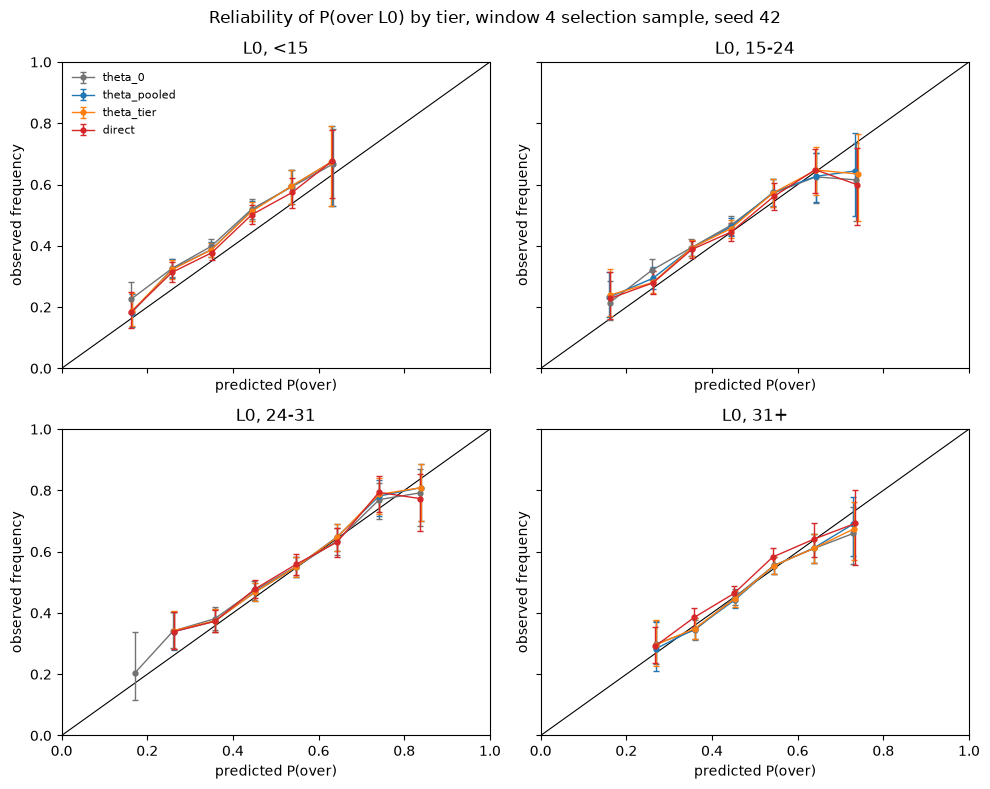

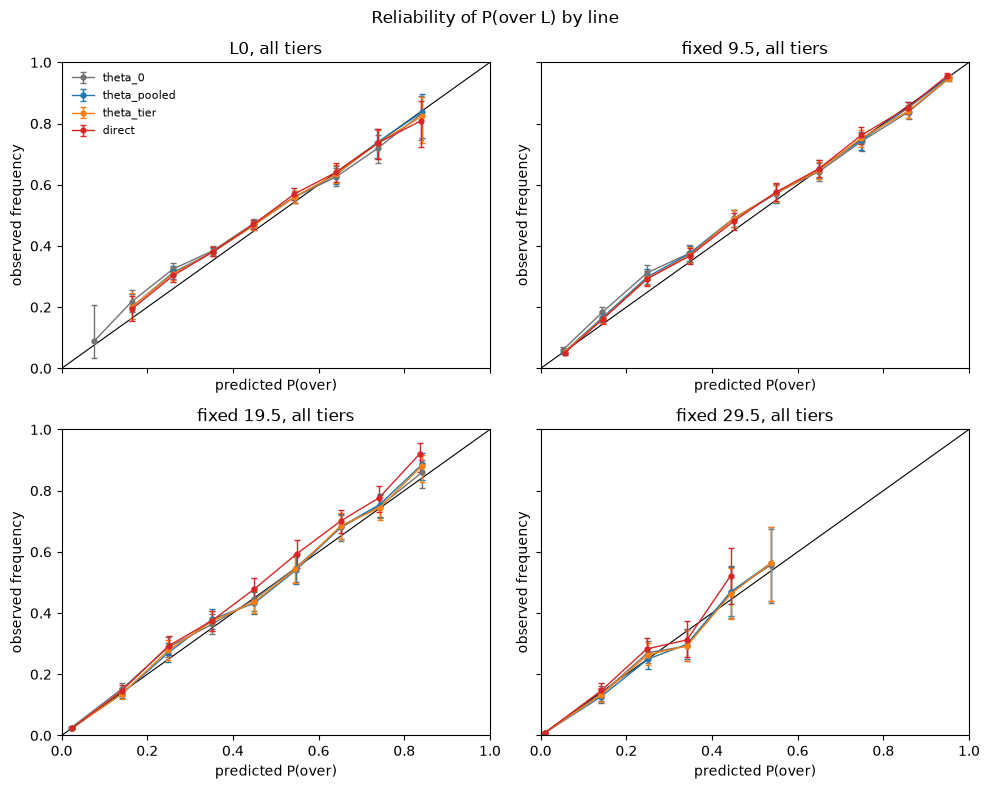

In [9]:
def reliability_rows(setup: str, line_name: str, lines: np.ndarray) -> list[dict]:
    valid = np.isfinite(lines)
    probability = np.full(len(lines), np.nan)
    probability[valid] = probability_over(pmfs[setup][valid], lines[valid])
    outcome = np.zeros(len(lines), dtype=bool)
    outcome[valid] = y_te[valid] > lines[valid]
    edges = np.linspace(0.0, 1.0, RELIABILITY_BINS + 1)
    records = []
    for slice_name, mask in slice_masks(tiers_te):
        base = mask & valid
        for index, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
            if index < RELIABILITY_BINS - 1:
                inside = base & (probability >= lo) & (probability < hi)
            else:
                inside = base & (probability >= lo) & (probability <= hi)
            n = int(inside.sum())
            if n < RELIABILITY_MIN_N:
                continue
            observed = float(np.mean(outcome[inside]))
            low, high = wilson_interval(int(outcome[inside].sum()), n)
            records.append({
                "setup": setup,
                "line": line_name,
                "slice": slice_name,
                "bin_lo": float(lo),
                "bin_hi": float(hi),
                "n": n,
                "predicted": float(np.mean(probability[inside])),
                "observed": observed,
                "wilson_low": low,
                "wilson_high": high,
                "gap": observed - float(np.mean(probability[inside])),
            })
    return records


reliability = pd.DataFrame([
    row
    for setup in SETUP_ORDER
    for line_name, lines in line_sets.items()
    for row in reliability_rows(setup, line_name, lines)
])


def draw_reliability(ax, frame, title: str, legend: bool) -> None:
    ax.plot([0, 1], [0, 1], color="black", lw=0.8, zorder=0)
    for setup in SETUP_ORDER:
        part = frame.loc[frame["setup"].eq(setup)].sort_values("bin_lo")
        if part.empty:
            continue
        yerr = np.vstack([
            np.maximum(part["observed"] - part["wilson_low"], 0.0),
            np.maximum(part["wilson_high"] - part["observed"], 0.0),
        ])
        ax.errorbar(
            part["predicted"], part["observed"], yerr=yerr, fmt="o-", ms=3.5, capsize=2, lw=1,
            color=SETUP_COLOR[setup], label=setup,
        )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel("predicted P(over)")
    ax.set_ylabel("observed frequency")
    if legend:
        ax.legend(frameon=False, fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, tier in zip(axes.ravel(), TIERS):
    part = reliability.loc[reliability["line"].eq("L0") & reliability["slice"].eq(tier)]
    draw_reliability(ax, part, f"L0, {tier}", legend=tier == "<15")
fig.suptitle(f"Reliability of P(over L0) by tier, window {TEST_WINDOW} selection sample, seed {SEED}")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, line_name in zip(axes.ravel(), ("L0", "fixed 9.5", "fixed 19.5", "fixed 29.5")):
    part = reliability.loc[reliability["line"].eq(line_name) & reliability["slice"].eq("all")]
    draw_reliability(ax, part, f"{line_name}, all tiers", legend=line_name == "L0")
fig.suptitle("Reliability of P(over L) by line")
fig.tight_layout()
plt.show()


### 5. Theta Sweep by Tier

Same four PMFs. The question is whether L0 Brier, and the log score, move when theta goes from 0 to 0.667, and when 15-24 and 31+ get their own taus. A difference whose game-clustered interval covers 0 is not distinguishable on this selection sample.


Brier at L0. Lower is better.


setup,theta_0,theta_pooled,theta_tier,direct
slice,,,,
all,0.23576,0.23534,0.23526,0.23503
<15,0.23481,0.23394,0.23384,0.23280
15-24,0.23447,0.23388,0.23365,0.23325
24-31,0.23403,0.23383,0.23382,0.23388
31+,0.23937,0.23936,0.23936,0.23980


Log score. Higher is better.


setup,theta_0,theta_pooled,theta_tier,direct
slice,,,,
all,-2.94792,-2.94203,-2.94150,-2.94443
<15,-2.28526,-2.27787,-2.27720,-2.27918
15-24,-2.94370,-2.93571,-2.93327,-2.93811
24-31,-3.17093,-3.16491,-3.16466,-3.16858
31+,-3.41295,-3.41058,-3.41168,-3.41295


,comparison,right,left,metric,slice,better_if,mean_diff,ci_low,ci_high,n_games,significant
0,theta_pooled - theta_0,theta_pooled,theta_0,log_score,all,positive,0.00589,0.00476,0.00699,717,True
4,theta_pooled - theta_0,theta_pooled,theta_0,brier L0,all,negative,-0.00042,-0.00054,-0.00030,717,True
13,theta_pooled - theta_0,theta_pooled,theta_0,log_score,<15,positive,0.00738,0.00537,0.00934,712,True
15,theta_pooled - theta_0,theta_pooled,theta_0,brier L0,<15,negative,-0.00087,-0.00117,-0.00058,712,True
16,theta_pooled - theta_0,theta_pooled,theta_0,log_score,15-24,positive,0.00799,0.00574,0.01037,716,True
18,theta_pooled - theta_0,theta_pooled,theta_0,brier L0,15-24,negative,-0.00059,-0.00083,-0.00033,716,True
19,theta_pooled - theta_0,theta_pooled,theta_0,log_score,24-31,positive,0.00602,0.00377,0.00799,714,True
21,theta_pooled - theta_0,theta_pooled,theta_0,brier L0,24-31,negative,-0.00020,-0.00040,-0.00000,714,True
22,theta_pooled - theta_0,theta_pooled,theta_0,log_score,31+,positive,0.00238,0.00051,0.00406,717,True
24,theta_pooled - theta_0,theta_pooled,theta_0,brier L0,31+,negative,-0.00000,-0.00017,0.00015,717,False


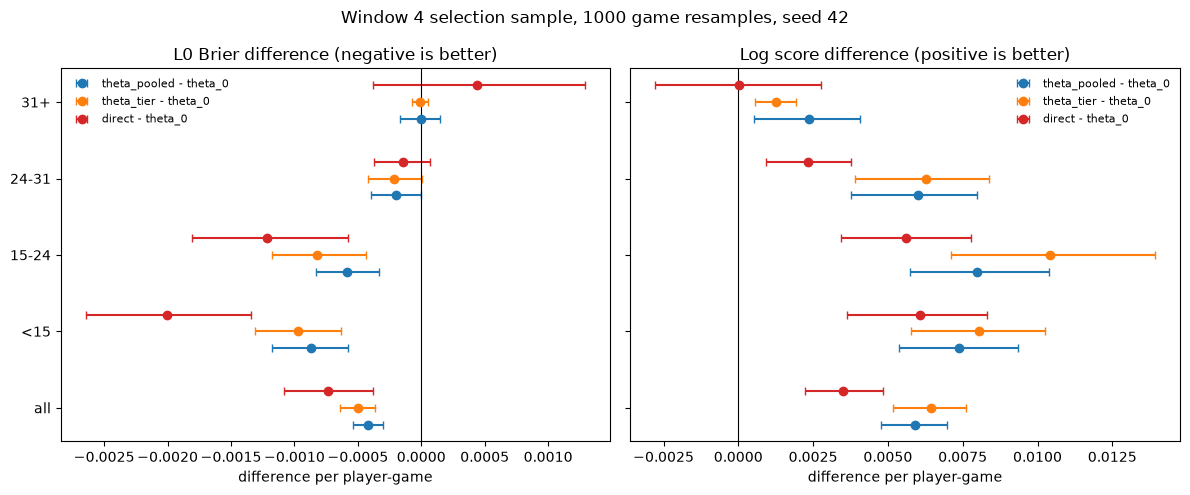

Brier by line, all tiers.


,L0-8,L0-4,L0,L0+4,L0+8,fixed 4.5,fixed 9.5,fixed 14.5,fixed 19.5,fixed 24.5,fixed 29.5
setup,,,,,,,,,,,
theta_0,0.13053,0.19951,0.23576,0.16537,0.08321,0.13807,0.14811,0.11934,0.08153,0.05150,0.02826
theta_pooled,0.13015,0.19922,0.23534,0.16500,0.08316,0.13779,0.14775,0.11917,0.08150,0.05151,0.02828
theta_tier,0.13008,0.19921,0.23526,0.16492,0.08309,0.13782,0.14772,0.11915,0.08150,0.05150,0.02827
direct,0.13083,0.19956,0.23503,0.16495,0.08308,0.13737,0.14751,0.11931,0.08178,0.05167,0.02832


In [10]:
l0 = levels.pivot(index="slice", columns="setup", values="brier L0").loc[SLICE_ORDER, SETUP_ORDER]
log_score = levels.pivot(index="slice", columns="setup", values="log_score").loc[SLICE_ORDER, SETUP_ORDER]
print("Brier at L0. Lower is better.")
display(l0.round(5))
print("Log score. Higher is better.")
display(log_score.round(5))

sweep = diffs.loc[diffs["metric"].isin(["brier L0", "log_score"])].copy()
display(sweep.round(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
metric_titles = {
    "brier L0": "L0 Brier difference (negative is better)",
    "log_score": "Log score difference (positive is better)",
}
for ax, metric in zip(axes, ("brier L0", "log_score")):
    part = sweep.loc[sweep["metric"].eq(metric) & sweep["comparison"].isin([
        "theta_pooled - theta_0", "theta_tier - theta_0", "direct - theta_0",
    ])]
    comparisons = ["theta_pooled - theta_0", "theta_tier - theta_0", "direct - theta_0"]
    offsets = np.linspace(-0.22, 0.22, len(comparisons))
    for offset, comparison in zip(offsets, comparisons):
        block = part.loc[part["comparison"].eq(comparison)].set_index("slice").loc[SLICE_ORDER]
        y = np.arange(len(SLICE_ORDER)) + offset
        color = "C3" if comparison.startswith("direct") else ("C1" if "tier" in comparison else "C0")
        ax.errorbar(
            block["mean_diff"], y,
            xerr=[block["mean_diff"] - block["ci_low"], block["ci_high"] - block["mean_diff"]],
            fmt="o", color=color, capsize=3, label=comparison,
        )
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(np.arange(len(SLICE_ORDER)))
    ax.set_yticklabels(SLICE_ORDER)
    ax.set_xlabel("difference per player-game")
    ax.set_title(metric_titles[metric])
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f"Window {TEST_WINDOW} selection sample, {SCORE_BOOT_REPS} game resamples, seed {SEED}")
fig.tight_layout()
plt.show()

brier_by_line = (
    levels.loc[levels["slice"].eq("all"), ["setup", *[f"brier {name}" for name in LINE_ORDER]]]
    .set_index("setup")
    .loc[SETUP_ORDER]
)
brier_by_line.columns = LINE_ORDER
print("Brier by line, all tiers.")
display(brier_by_line.round(5))


### 6. Market Backtest

Window 5 points props from `data/backtest/singleBookies.csv`, priced by every setup above plus a fully out-of-sample path:

**- `theta_train`:** Frank with theta matched to the windows 1-4 Kendall tau, count model on windows 1-4, read from the quadrature PMF.

**- `theta_train simulated`:** the same model priced the way the live simulator would price it. `U` is drawn, pushed through the minutes quantile function, `V | U` comes from Frank `hinv1`, and points are the NB2 quantile at `V`. `P(over L)` is the share of `N_SIMS` draws over the line, with pushes removed. Its gap from the `theta_train` PMF should sit inside Monte Carlo error; anything larger is a wiring bug.

`theta_pooled` and `theta_tier` use dependence fit on windows 1-5, so window 5 is inside them. `direct` and both `theta_train` setups use nothing from window 5.

Consensus rows use the line quoted by the most books, the best price across books for bets, and the de-vigged median price as the benchmark. By-book rows use each book's own line and price. A bet goes on the higher-EV side when its EV exceeds `EDGE_THRESHOLD`, which was fixed before this ran. The EV buckets include every line and are a diagnostic, not a way to pick the threshold.

In [ ]:
if not ODDS_PATH.exists():
    raise FileNotFoundError(f"{ODDS_PATH.relative_to(ROOT)} is needed for the market backtest")

odds_logs = pd.concat(
    [pd.read_parquet(str(DATA_PATH).format(season=season), columns=["player_id", "player_name", "game_id", "game_date"])
     for season in PREHOLDOUT_SEASONS],
    ignore_index=True,
)
odds, book_odds = load_single_bookies(ODDS_PATH, odds_logs, min_books=ODDS_MIN_BOOKS, aliases=ODDS_NAME_ALIASES)
for frame in (odds, book_odds):
    frame["game_key"] = frame["game_id"].map(canonical_id)
    frame["player_key"] = frame["player_id"].map(canonical_id)
consensus_cols = (odds[["game_key", "player_key", "line", "over_close", "under_close"]]
                  .rename(columns={"line": "consensus_line"}))
test_rows = test.reset_index(names="row")[["row", "game_key", "player_key", "pts"]]
m = test_rows.merge(odds, on=["game_key", "player_key"], how="inner")
mb = (test_rows.merge(book_odds, on=["game_key", "player_key"], how="inner")
      .merge(consensus_cols, on=["game_key", "player_key"], how="left"))
print(f"Odds: matched {odds.attrs['match_rate']:.1%} of {odds.attrs['n_quotes']:,} two-sided book lines to gamelogs")
print(f"Window {TEST_WINDOW}: {len(m):,} consensus lines, {len(mb):,} book quotes from {mb['book'].nunique()} books")

tau_train = kendall(train["u_minutes"], train["u_points"])
theta_train = frank_theta_for_tau(tau_train)
train_copula = frank_copula(theta_train)
print(f"Train-only Frank: tau {tau_train:.4f}, theta {theta_train:.4f} (exported theta {EXPORTED_THETA:.4f})")
started = time.perf_counter()
pmf_train = points_pmf(count_tr, train_copula)
print(f"theta_train: {len(test):,} PMFs in {time.perf_counter() - started:.1f}s")

sim_rows = np.union1d(m["row"].to_numpy(), mb["row"].to_numpy())
sim_points = np.empty((len(sim_rows), N_SIMS), dtype=np.int16)
sim_rng = np.random.default_rng(SEED + 11)
started = time.perf_counter()
for start in range(0, len(sim_rows), SIM_BATCH_ROWS):
    block = sim_rows[start:start + SIM_BATCH_ROWS]
    sample = test.iloc[block]
    lower, upper = minutes_groups(sample["starting"], minutes_tables)
    u = sim_rng.random((len(block), N_SIMS))
    w = sim_rng.random((len(block), N_SIMS))
    v = np.asarray(train_copula.hinv1(np.column_stack([u.ravel(), w.ravel()])), dtype=float).reshape(u.shape)
    minutes_sim = minutes_ppf(u, sample[MINUTES_KNOTS].to_numpy(dtype=float), lower, upper, minutes_tables)
    mu = count_tr.mean(minutes_sim, sample["rate_hat"].to_numpy(dtype=float)[:, None])
    alpha = count_tr.alpha(minutes_sim, sample["rate_cv"].to_numpy(dtype=float)[:, None])
    sim_points[start:start + len(block)] = np.minimum(nb_ppf(v, mu, alpha), SIM_POINTS_CAP).astype(np.int16)
sim_position = pd.Series(np.arange(len(sim_rows)), index=sim_rows)
print(f"Simulated {len(sim_rows):,} player-games x {N_SIMS:,} joint draws in {time.perf_counter() - started:.1f}s")


def simulated_over(rows_idx, lines, chunk: int = 5_000) -> np.ndarray:
    """Share of joint draws over the line, pushes removed."""
    positions = sim_position.loc[rows_idx].to_numpy()
    lines = np.asarray(lines, dtype=float)
    out = np.empty(len(positions))
    for start in range(0, len(positions), chunk):
        draws = sim_points[positions[start:start + chunk]]
        line = lines[start:start + chunk, None]
        over = (draws > line).sum(axis=1)
        push = (draws == line).sum(axis=1)
        out[start:start + chunk] = over / np.maximum(N_SIMS - push, 1)
    return out


setup_pmfs = {**pmfs, "theta_train": pmf_train}
MARKET_SETUPS = [*SETUP_ORDER, "theta_train", "theta_train simulated"]
DEPENDENCE_FIT = {
    "theta_0": "none",
    "theta_pooled": f"windows {ALL_LABEL} (includes test)",
    "theta_tier": f"windows {ALL_LABEL} (includes test)",
    "direct": f"windows {TRAIN_LABEL}",
    "theta_train": f"windows {TRAIN_LABEL}",
    "theta_train simulated": f"windows {TRAIN_LABEL}",
}


def model_over(setup: str, frame: pd.DataFrame) -> np.ndarray:
    rows_idx = frame["row"].to_numpy()
    lines = frame["line"].to_numpy(dtype=float)
    if setup == "theta_train simulated":
        return simulated_over(rows_idx, lines)
    return over_given_no_push(setup_pmfs[setup][rows_idx], lines)


p_quad = model_over("theta_train", m)
p_sim = model_over("theta_train simulated", m)
mc_se = np.sqrt(np.clip(p_quad * (1 - p_quad), 1e-6, None) / N_SIMS)
print(f"Simulated vs quadrature P(over), consensus lines: mean |diff| {np.mean(np.abs(p_sim - p_quad)):.4f}, "
      f"share beyond 3 Monte Carlo SE {np.mean(np.abs(p_sim - p_quad) > 3 * mc_se):.2%} (about 0.3% expected)")

market_kwargs = dict(edge_threshold=EDGE_THRESHOLD, n_boot=SCORE_BOOT_REPS, seed=SEED)
p_close = no_vig_over(m["over_close"], m["under_close"])
market_rows = []
for setup in MARKET_SETUPS:
    market, bets = score_market(model_over(setup, m), m, p_close, p_close, **market_kwargs)
    market_rows.append({"setup": setup, "dependence_fit": DEPENDENCE_FIT[setup], **market, **(bets or {"n_bets": 0})})
market_table = pd.DataFrame(market_rows)

book_rows = []
for book, g in mb.groupby("book"):
    g = g.reset_index(drop=True)
    p_book = no_vig_over(g["over_bet"], g["under_bet"])
    p_consensus = np.where(g["line"].eq(g["consensus_line"]), no_vig_over(g["over_close"], g["under_close"]), np.nan)
    for setup in ("theta_0", "theta_train simulated"):
        market, bets = score_market(model_over(setup, g), g, p_book, p_consensus, **market_kwargs)
        book_rows.append({"book": book, "setup": setup, **market, **(bets or {"n_bets": 0})})
market_by_book = pd.DataFrame(book_rows)

p_consensus_mb = np.where(mb["line"].eq(mb["consensus_line"]), no_vig_over(mb["over_close"], mb["under_close"]), np.nan)
bucket_rows = []
for source, frame, p_cons in (("best price", m, p_close), ("each book", mb, p_consensus_mb)):
    for record in ev_bucket_records(model_over("theta_train simulated", frame), frame, p_cons,
                                    n_boot=SCORE_BOOT_REPS, seed=SEED):
        bucket_rows.append({"source": source, "setup": "theta_train simulated", **record})
market_buckets = pd.DataFrame(bucket_rows)

print(f"Window {TEST_WINDOW}. Positive market_minus_model_logloss means the model beats the de-vigged market.")
print("Consensus line, bets at the best price across books:")
display(market_table.round(4))
print("By book, each book's own line and price:")
display(market_by_book.round(4))
print("ROI by EV bucket, theta_train simulated (diagnostic, every line included):")
display(market_buckets.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
bet_setups = market_table.loc[market_table["n_bets"] > 0]
y = np.arange(len(bet_setups))
axes[0].errorbar(bet_setups["roi"], y,
                 xerr=[bet_setups["roi"] - bet_setups["roi_ci_low"], bet_setups["roi_ci_high"] - bet_setups["roi"]],
                 fmt="o", capsize=3)
axes[0].set_yticks(y, bet_setups["setup"])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("ROI per bet (95% game bootstrap)")
axes[0].set_title(f"Window {TEST_WINDOW} ROI at EV > {EDGE_THRESHOLD:.0%}, best price")
for source, g in market_buckets.groupby("source"):
    x = np.arange(len(g))
    axes[1].errorbar(x, g["roi"], yerr=[g["roi"] - g["roi_ci_low"], g["roi_ci_high"] - g["roi"]],
                     marker="o", capsize=3, label=source)
    axes[1].set_xticks(x, g["ev_bucket"].astype(str))
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("model EV of chosen side")
axes[1].set_ylabel("ROI per bet")
axes[1].set_title("theta_train simulated: ROI by EV bucket")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

### 7. Bookkeeping

Saved tables repeat the seed, the spec status, the file hashes, and the exported theta. Window 5 is marked `selection_sample`. The 2025-26 holdout is marked sealed and was not scored.

In [11]:
tau_path = OUTPUT_PATH / "recovered_tau.csv"
corner_path = OUTPUT_PATH / "corner_lifts.csv"
diag_path = OUTPUT_PATH / "roundtrip_diagnostics.csv"
theta_path = OUTPUT_PATH / "tier_thetas.csv"
level_path = OUTPUT_PATH / "line_scores.csv"
diff_path = OUTPUT_PATH / "score_diffs.csv"
reliability_path = OUTPUT_PATH / "reliability.csv"
stamp_path = OUTPUT_PATH / "run_stamp.json"
market_path = OUTPUT_PATH / "market_backtest.csv"
market_book_path = OUTPUT_PATH / "market_by_book.csv"
market_bucket_path = OUTPUT_PATH / "market_ev_buckets.csv"

with_stamp(tau_table, count_model_windows=ALL_LABEL, theta=EXPORTED_THETA).to_csv(tau_path, index=False)
with_stamp(corner_wide, count_model_windows=ALL_LABEL, theta=EXPORTED_THETA).to_csv(corner_path, index=False)
with_stamp(roundtrip_diag, count_model_windows=ALL_LABEL, theta=EXPORTED_THETA).to_csv(diag_path, index=False)
with_stamp(tier_thetas, count_model_windows=ALL_LABEL).to_csv(theta_path, index=False)
with_stamp(levels, count_model_windows=TRAIN_LABEL, scored_window=TEST_WINDOW, scored_window_role="selection_sample").to_csv(level_path, index=False)
with_stamp(diffs, count_model_windows=TRAIN_LABEL, scored_window=TEST_WINDOW, scored_window_role="selection_sample").to_csv(diff_path, index=False)
with_stamp(reliability, count_model_windows=TRAIN_LABEL, scored_window=TEST_WINDOW, scored_window_role="selection_sample").to_csv(reliability_path, index=False)
if ODDS_PATH.exists():
    for table, path in ((market_table, market_path), (market_by_book, market_book_path), (market_buckets, market_bucket_path)):
        with_stamp(table, count_model_windows=TRAIN_LABEL, scored_window=TEST_WINDOW, scored_window_role="selection_sample",
                   theta_train=theta_train, n_sims=N_SIMS, edge_threshold=EDGE_THRESHOLD).to_csv(path, index=False)

stamp = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    **LINEAGE_STAMP,
    "n_per_tier": N_PER_TIER,
    "minutes_grid": MINUTES_GRID,
    "score_bootstrap": SCORE_BOOT_REPS,
    "test_window": TEST_WINDOW,
    "test_window_role": "selection_sample",
    "pmf_count_model": f"windows {TRAIN_LABEL}",
    "wiring_count_model": f"windows {ALL_LABEL}",
    "theta_pooled_source": f"exported spec, windows {ALL_LABEL}",
    "theta_tier_source": f"Frank matched to windows {ALL_LABEL} empirical tau",
    "direct_model": f"windows {TRAIN_LABEL} with Phi^{{-1}}(u_minutes) in the log mean",
    "holdout_loaded": False,
    "odds_file": str(ODDS_PATH.relative_to(ROOT)),
    "edge_threshold": EDGE_THRESHOLD,
    "n_sims": N_SIMS,
    "tier_thetas": {row.tier: row.frank_theta for row in tier_thetas.itertuples()},
    "spec_note": spec["status_note"],
}
stamp_path.write_text(json.dumps(stamp, indent=2))
print(f"Wrote {OUTPUT_PATH.relative_to(ROOT)}")

Wrote artifacts/nba/copula/simulator_checks


### Results


In [12]:
def _diff_row(comparison: str, metric: str, slice_name: str = "all"):
    hit = diffs.loc[
        diffs["comparison"].eq(comparison) & diffs["metric"].eq(metric) & diffs["slice"].eq(slice_name)
    ]
    return hit.iloc[0]


def _fmt_diff(row) -> str:
    flag = "excludes 0" if row["significant"] else "covers 0"
    return f"{row['mean_diff']:+.5f} [{row['ci_low']:+.5f}, {row['ci_high']:+.5f}] ({flag})"


overall = tau_table.set_index("slice").loc["all"]
corners_all = corner_wide.loc[corner_wide["slice"].eq("all")]
ll_01 = corners_all.loc[np.isclose(corners_all["q"], 0.01) & corners_all["corner"].eq("low_u_low_v")].iloc[0]
hh_01 = corners_all.loc[np.isclose(corners_all["q"], 0.01) & corners_all["corner"].eq("high_u_high_v")].iloc[0]
ll_10 = corners_all.loc[np.isclose(corners_all["q"], 0.10) & corners_all["corner"].eq("low_u_low_v")].iloc[0]
hh_10 = corners_all.loc[np.isclose(corners_all["q"], 0.10) & corners_all["corner"].eq("high_u_high_v")].iloc[0]
tier_tau_text = ", ".join(
    f"{row.tier} empirical {row.tau_all_windows:.3f} (Frank theta {row.frank_theta:.3f})"
    for row in tier_thetas.itertuples()
)
l0_levels = levels.loc[levels["slice"].eq("all")].set_index("setup")
pooled_l0 = _diff_row("theta_pooled - theta_0", "brier L0")
tier_l0 = _diff_row("theta_tier - theta_0", "brier L0")
tier_vs_pooled_l0 = _diff_row("theta_tier - theta_pooled", "brier L0")
direct_l0 = _diff_row("direct - theta_pooled", "brier L0")
pooled_ll = _diff_row("theta_pooled - theta_0", "log_score")
tier_ll = _diff_row("theta_tier - theta_0", "log_score")
direct_ll = _diff_row("direct - theta_pooled", "log_score")

latent_gap = abs(float(overall["latent_minus_target"]))
latent_ok = latent_gap < 3 * float(overall["null_se"])
wiring_text = (
    f"Latent tau is {overall['latent_tau']:.4f} against the exported {TARGET_TAU:.4f} "
    f"(gap {overall['latent_minus_target']:+.4f}, null SE {overall['null_se']:.4f}). "
    + ("That is inside 3 null SE." if latent_ok else "That is outside 3 null SE, so the conditional draw is off.")
)
inversion_text = (
    f"The inverting-atom tau is {overall['inversion_tau']:.4f} and the largest points inversion error is "
    f"{roundtrip_diag['max_points_inversion_error'].max():.2e}, so the NB2 quantile and the randomized PIT agree."
)
by_tier = tau_table.set_index("slice")
short = by_tier.loc["<15"]
stars = by_tier.loc["31+"]
latent_by_tier = ", ".join(f"{name} {by_tier.loc[name, 'latent_tau']:.3f}" for name in TIERS)
empirical_by_tier = ", ".join(f"{name} {by_tier.loc[name, 'empirical_tau']:.3f}" for name in TIERS)
wiring_text += (
    f" Latent tau by tier is {latent_by_tier}. Empirical tau on the same tiers is {empirical_by_tier}. "
    "The simulated dependence stays at the pooled value because the exported copula has one theta."
)
discrete_text = (
    f"A fresh atom moves overall tau by {overall['roundtrip_minus_latent']:+.4f}, to {overall['roundtrip_tau']:.4f}. "
    f"Below 15 predicted minutes the mean NB2 atom width is {short['mean_points_atom_width']:.3f} and "
    f"round-trip tau falls to {short['roundtrip_tau']:.3f} from latent {short['latent_tau']:.3f}. "
    f"At 31+ the atom width is {stars['mean_points_atom_width']:.3f} and round-trip tau is {stars['roundtrip_tau']:.3f}. "
    f"Mean minutes PIT error is {roundtrip_diag['mean_minutes_pit_error'].mean():.2e}. "
    f"The worst short-stint minutes draw misses U by {roundtrip_diag['max_minutes_pit_error'].max():.3f}."
)
ll_gap_10 = float(ll_10["empirical"] - ll_10["theoretical"])
if ll_gap_10 > 0.05:
    gap_clause = (
        "The q = 0.10 lower-left gap is the stable one: empirical pairs sit above Frank, "
        "and the latent draws match Frank."
    )
else:
    gap_clause = "Latent and theoretical lifts agree at q = 0.10."
tail_text = (
    f"At q = 0.10, lower-left lift is empirical {ll_10['empirical']:.2f}, latent {ll_10['latent']:.2f}, "
    f"theoretical {ll_10['theoretical']:.2f}. Upper-right is empirical {hh_10['empirical']:.2f}, "
    f"latent {hh_10['latent']:.2f}, theoretical {hh_10['theoretical']:.2f}. "
    f"{gap_clause} "
    f"At q = 0.01 the empirical corners contain {int(ll_01['empirical_count'])} and {int(hh_01['empirical_count'])} pairs "
    f"(lifts {ll_01['empirical']:.2f} and {hh_01['empirical']:.2f}), which is too few to measure the tail. "
    f"Latent lifts there are {ll_01['latent']:.2f} and {hh_01['latent']:.2f} against Frank {ll_01['theoretical']:.2f}."
)
tier_vs_pooled_ll = _diff_row("theta_tier - theta_pooled", "log_score")
tier_l0_slices = diffs.loc[
    diffs["comparison"].eq("theta_tier - theta_pooled")
    & diffs["metric"].eq("brier L0")
    & diffs["slice"].isin(TIERS)
]
best_tier = tier_l0_slices.loc[tier_l0_slices["mean_diff"].idxmin()]
worth = (
    f"Pooled Frank changes L0 Brier by {pooled_l0['mean_diff']:+.5f} and the tier split adds "
    f"{tier_vs_pooled_l0['mean_diff']:+.5f}. Both intervals exclude 0. "
    f"The Brier level is {l0_levels.loc['theta_0', 'brier L0']:.3f}, so both shifts are under 0.001. "
    f"The largest tier contrast is {best_tier['slice']} at {best_tier['mean_diff']:+.5f}. "
    f"Log score moves by {pooled_ll['mean_diff']:+.4f} nats for pooled Frank over independence, "
    f"and the tier split adds {tier_vs_pooled_ll['mean_diff']:+.4f}. "
    "The line price barely moves. The log score is where the copula shows up."
)

display(Markdown(f"""
**- Wiring:** {wiring_text} {inversion_text} {discrete_text}

**- Corners:** {tail_text}

**- Tier taus used in the sweep:** {tier_tau_text}. These taus include window {TEST_WINDOW}.

**- L0 Brier on window {TEST_WINDOW} (lower is better):** independence {l0_levels.loc['theta_0', 'brier L0']:.5f}, pooled {l0_levels.loc['theta_pooled', 'brier L0']:.5f}, tier {l0_levels.loc['theta_tier', 'brier L0']:.5f}, direct {l0_levels.loc['direct', 'brier L0']:.5f}.

**- L0 Brier differences:** pooled minus independence {_fmt_diff(pooled_l0)}. Tier minus independence {_fmt_diff(tier_l0)}. Tier minus pooled {_fmt_diff(tier_vs_pooled_l0)}. Direct minus pooled {_fmt_diff(direct_l0)}.

**- Log score differences (higher is better):** pooled minus independence {_fmt_diff(pooled_ll)}. Tier minus independence {_fmt_diff(tier_ll)}. Direct minus pooled {_fmt_diff(direct_ll)}.

**- Sweep:** {worth}

**- Sample label:** window {TEST_WINDOW} is the selection sample. 2025-26 was not loaded. Seed {SEED}. Exported theta {EXPORTED_THETA:.6f}. Spec status `{spec['status']}`.
"""))


**- Wiring:** Latent tau is 0.0744 against the exported 0.0738 (gap +0.0006, null SE 0.0015). That is inside 3 null SE. Latent tau by tier is <15 0.077, 15-24 0.073, 24-31 0.073, 31+ 0.074. Empirical tau on the same tiers is <15 0.084, 15-24 0.112, 24-31 0.079, 31+ 0.028. The simulated dependence stays at the pooled value because the exported copula has one theta. The inverting-atom tau is 0.0744 and the largest points inversion error is 5.55e-17, so the NB2 quantile and the randomized PIT agree. A fresh atom moves overall tau by -0.0046, to 0.0698. Below 15 predicted minutes the mean NB2 atom width is 0.244 and round-trip tau falls to 0.062 from latent 0.077. At 31+ the atom width is 0.045 and round-trip tau is 0.074. Mean minutes PIT error is 2.35e-06. The worst short-stint minutes draw misses U by 0.165.

**- Corners:** At q = 0.10, lower-left lift is empirical 1.61, latent 1.26, theoretical 1.29. Upper-right is empirical 1.37, latent 1.31, theoretical 1.29. The q = 0.10 lower-left gap is the stable one: empirical pairs sit above Frank, and the latent draws match Frank. At q = 0.01 the empirical corners contain 7 and 15 pairs (lifts 1.16 and 2.48), which is too few to measure the tail. Latent lifts there are 1.40 and 1.45 against Frank 1.36.

**- Tier taus used in the sweep:** <15 empirical 0.084 (Frank theta 0.759), 15-24 empirical 0.112 (Frank theta 1.016), 24-31 empirical 0.079 (Frank theta 0.712), 31+ empirical 0.028 (Frank theta 0.248). These taus include window 4.

**- L0 Brier on window 4 (lower is better):** independence 0.23576, pooled 0.23534, tier 0.23526, direct 0.23503.

**- L0 Brier differences:** pooled minus independence -0.00042 [-0.00054, -0.00030] (excludes 0). Tier minus independence -0.00050 [-0.00064, -0.00036] (excludes 0). Tier minus pooled -0.00008 [-0.00013, -0.00004] (excludes 0). Direct minus pooled -0.00032 [-0.00062, -0.00000] (excludes 0).

**- Log score differences (higher is better):** pooled minus independence +0.00589 [+0.00476, +0.00699] (excludes 0). Tier minus independence +0.00643 [+0.00519, +0.00761] (excludes 0). Direct minus pooled -0.00240 [-0.00334, -0.00140] (excludes 0).

**- Sweep:** Pooled Frank changes L0 Brier by -0.00042 and the tier split adds -0.00008. Both intervals exclude 0. The Brier level is 0.236, so both shifts are under 0.001. The largest tier contrast is 15-24 at -0.00023. Log score moves by +0.0059 nats for pooled Frank over independence, and the tier split adds +0.0005. The line price barely moves. The log score is where the copula shows up.

**- Sample label:** window 4 is the selection sample. 2025-26 was not loaded. Seed 42. Exported theta 0.667364. Spec status `exploratory_oos`.


### Conclusion


In [13]:
if not latent_ok:
    verdict = (
        "The simulator does not recover the exported tau, so fix the conditional draw or the quantile "
        "inversion before reading the scores."
    )
else:
    verdict = (
        f"The exported Frank simulator recovers tau {overall['latent_tau']:.4f} against the exported {TARGET_TAU:.4f}, "
        f"including inside each predicted-minutes tier. "
        f"On L0 Brier, pooled minus independence is {pooled_l0['mean_diff']:+.5f}, "
        f"tier minus pooled is {tier_vs_pooled_l0['mean_diff']:+.5f}, and "
        f"direct minus pooled is {direct_l0['mean_diff']:+.5f}. "
        "Those intervals exclude 0, and each shift is under 0.001 on a Brier near 0.236. "
        f"Log score is the metric that moves: pooled minus independence is {pooled_ll['mean_diff']:+.4f} nats, "
        f"and direct minus pooled is {direct_ll['mean_diff']:+.4f}. "
        "The direct model still leads at the line and trails on the full PMF."
    )
if ll_gap_10 > 0.05:
    tail_verdict = (
        f"Frank understates the q = 0.10 lower-left corner "
        f"({ll_10['empirical']:.2f} empirical versus {ll_10['theoretical']:.2f} theoretical), "
        f"and the latent draws sit on the theoretical value ({ll_10['latent']:.2f}). "
        f"The upper-right gap at that cutoff is smaller ({hh_10['empirical']:.2f} versus {hh_10['theoretical']:.2f}). "
    )
else:
    tail_verdict = (
        f"At q = 0.10 the latent lower-left lift is {ll_10['latent']:.2f} against Frank {ll_10['theoretical']:.2f}. "
    )
tail_verdict += (
    f"The q = 0.01 empirical lifts rest on {int(ll_01['empirical_count'])} and {int(hh_01['empirical_count'])} pairs. "
    "A heavier-tailed family would have to be scored at the lines before it is a reason to replace Frank, "
    "because this theta sweep already shows that dependence of this size does not move L0."
)
display(Markdown(f"""
**- Verdict:** {verdict}

{tail_verdict} Window {TEST_WINDOW} has already been used to choose a family and to set these thetas, so that comparison still belongs on a sample that was not used for selection. 2025-26 stays sealed until the scored PMF and the exported spec are the same object.
"""))


**- Verdict:** The exported Frank simulator recovers tau 0.0744 against the exported 0.0738, including inside each predicted-minutes tier. On L0 Brier, pooled minus independence is -0.00042, tier minus pooled is -0.00008, and direct minus pooled is -0.00032. Those intervals exclude 0, and each shift is under 0.001 on a Brier near 0.236. Log score is the metric that moves: pooled minus independence is +0.0059 nats, and direct minus pooled is -0.0024. The direct model still leads at the line and trails on the full PMF.

Frank understates the q = 0.10 lower-left corner (1.61 empirical versus 1.29 theoretical), and the latent draws sit on the theoretical value (1.26). The upper-right gap at that cutoff is smaller (1.37 versus 1.29). The q = 0.01 empirical lifts rest on 7 and 15 pairs. A heavier-tailed family would have to be scored at the lines before it is a reason to replace Frank, because this theta sweep already shows that dependence of this size does not move L0. Window 4 has already been used to choose a family and to set these thetas, so that comparison still belongs on a sample that was not used for selection. 2025-26 stays sealed until the scored PMF and the exported spec are the same object.
